# Como criar uma rede Neural ?

In [26]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt


In [27]:
class LineNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential( #o Sequential é usado para momentos em que temos mais de uma camada, neste caso, temos apenas uma camada
        nn.Linear(1,1) #diz que o neurônio pega um valor e devolve apenas um valor também
    )

    self.layers = nn.Linear(1,1)

  #diz o que a rede vai fazer com o dado que entra
  def forward(self, x):
    return  self.layers(x)




# Como treinar sua Rede Neural

## 3.1 Preparando a Infraestrutura de Dados

In [28]:
from torch.utils.data import Dataset, DataLoader
import torch.distributions.uniform as urand

In [29]:

class AlgebraicDataset(Dataset):
  def __init__(self, f, interval,nsamples): # f é a função do modelo, interval é o intervalo numérico dos pontos e nsamples é a quantidade de pontos que temos na amostra
    X = urand.Uniform(interval[0], interval[1]).sample([nsamples])
    self.data = [(x, f(x)) for x in X ]

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx]

In [30]:
line = lambda x: 2*x + 3
interval = (-10,10)
train_nsamples = 1000
test_nsamples = 100

In [31]:
train_data = AlgebraicDataset(line, interval, train_nsamples)
test_data = AlgebraicDataset(line, interval, test_nsamples)

train_dataloader = DataLoader(train_data, batch_size = 32, shuffle=True) #batch_size diz a quantidade de dados que serão fornecidos,
                                      #pois em situações em que há uma grande quantidade de dados é muito ruim processá-los todos de uma só vez
                                      #Shuffle -> embaralha os dados
test_dataloader = DataLoader(test_data, batch_size = test_nsamples, shuffle=True)

## 3.2 Hiperparâmetros de Otimização

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Rodando em {device}')

Rodando em cpu


In [33]:
model = LineNetwork()

In [34]:
#Função de perda (Loss Func)
lossfunc = nn.MSELoss() #MSE - Mean Square Error
#SGD = Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) #lr - learning rate

In [35]:
def train(model, dataloader, lossfunc, optimizer):
  model.train()

  cumloss = 0.0

  for X, y in dataloader:
    X = X.unsqueeze(1).float().to(device)
    y = y.unsqueeze(1).float().to(device)

    pred = model(X)
    loss = lossfunc(pred, y)
    # zera os gradientes acumulados
    optimizer.zero_grad()
    # computa os valores do gradiente "voltando para trás"
    loss.backward()
    # "anda" na direção e sentido determinado anteriormente na direção que reduz o erro local
    optimizer.step()

    cumloss += loss.item()

  return cumloss/len(dataloader)

def test(model, dataloader, lossfunc):
  model.eval()
  cumloss = 0.0
  with torch.no_grad():
    for X, y in dataloader:
      X = X.unsqueeze(1).float().to(device)
      y = y.unsqueeze(1).float().to(device)

      pred = model(X)
      loss = lossfunc(pred, y)

      cumloss += loss.item()

  return cumloss/len(dataloader)

## 3.3 Treinando a rede

In [36]:
def plot_comparinson(f, model, interval = (-10,10), nsamples = 10):
  fig, ax = plt.subplots(figsize = (10,10))

  ax.grid(True, which='both')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['top'].set_color('none')

  samples = np.linspace(interval[0], interval[1], nsamples)
  model.eval()
  with torch.no_grad():
    pred = model(torch.tensor(samples).unsqueeze(1).float().to(device))

  ax.plot(samples, list(map(f, samples)), "o", label = "ground truth")
  ax.plot(samples, pred.cpu(), label = "model")
  plt.legend()
  plt.show()

Epoach: 0; Train Loss: 36.675692826509476


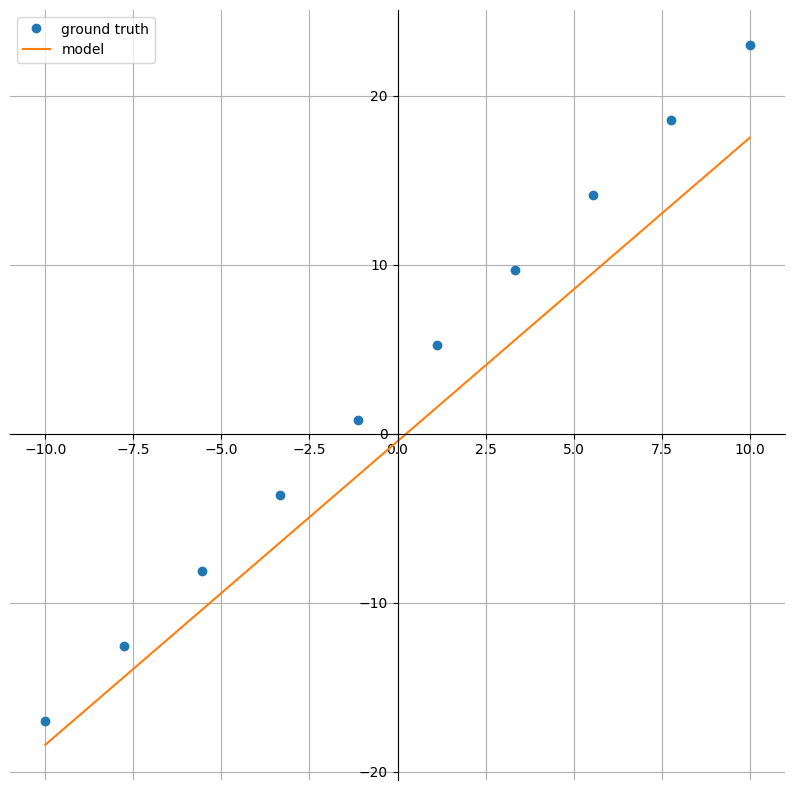

Epoach: 10; Train Loss: 3.555000975728035


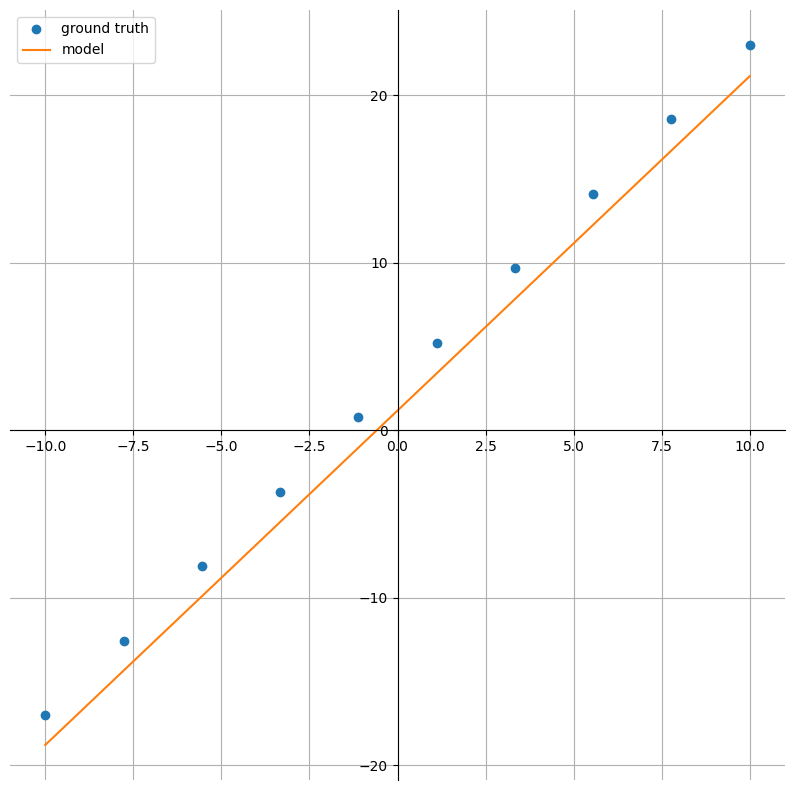

Epoach: 20; Train Loss: 0.9860535990446806


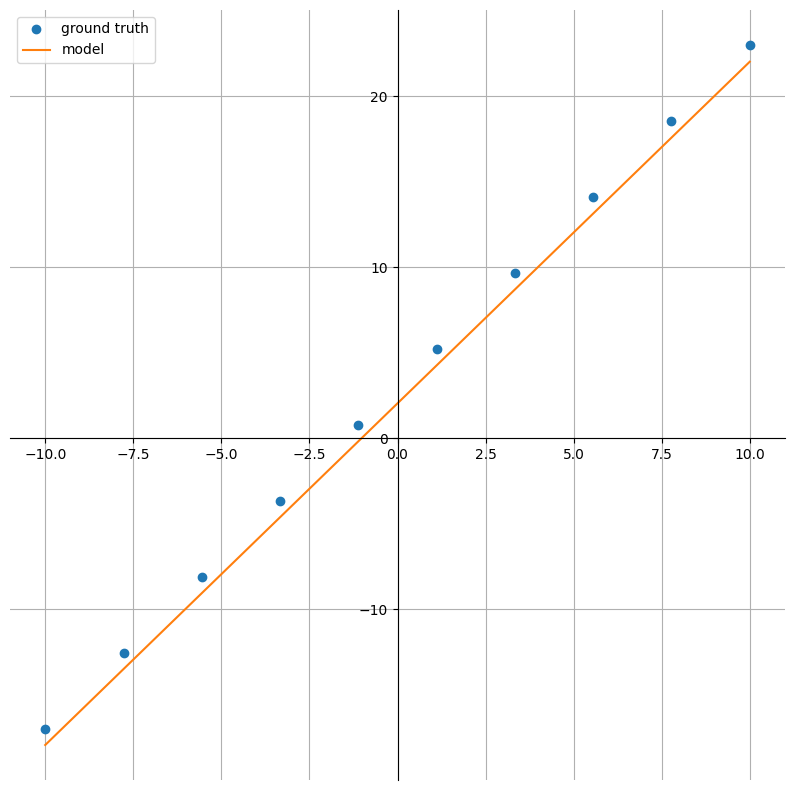

Epoach: 30; Train Loss: 0.27338740788400173


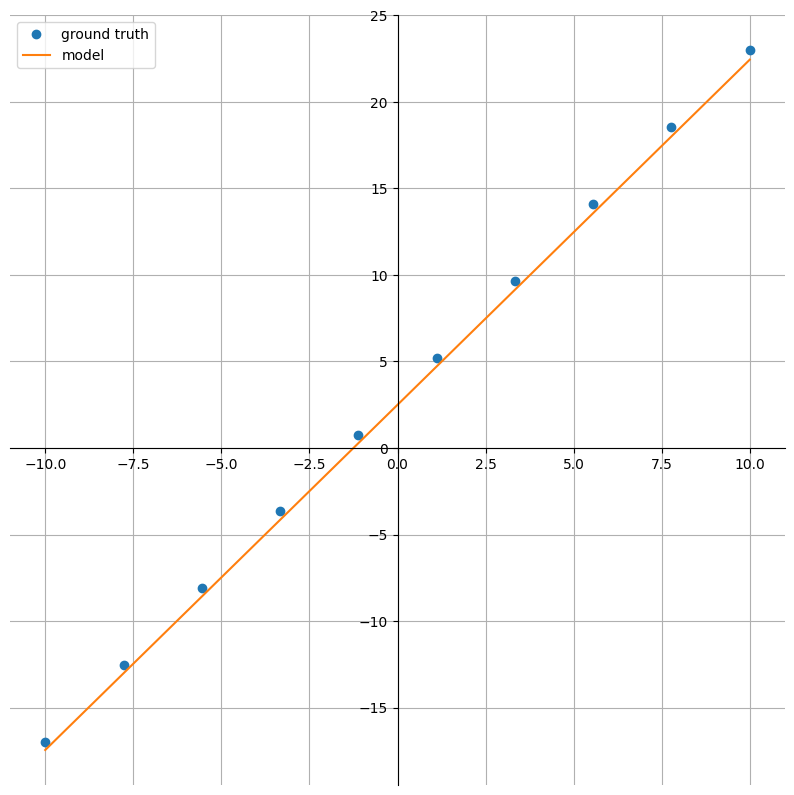

Epoach: 40; Train Loss: 0.07589624729007483


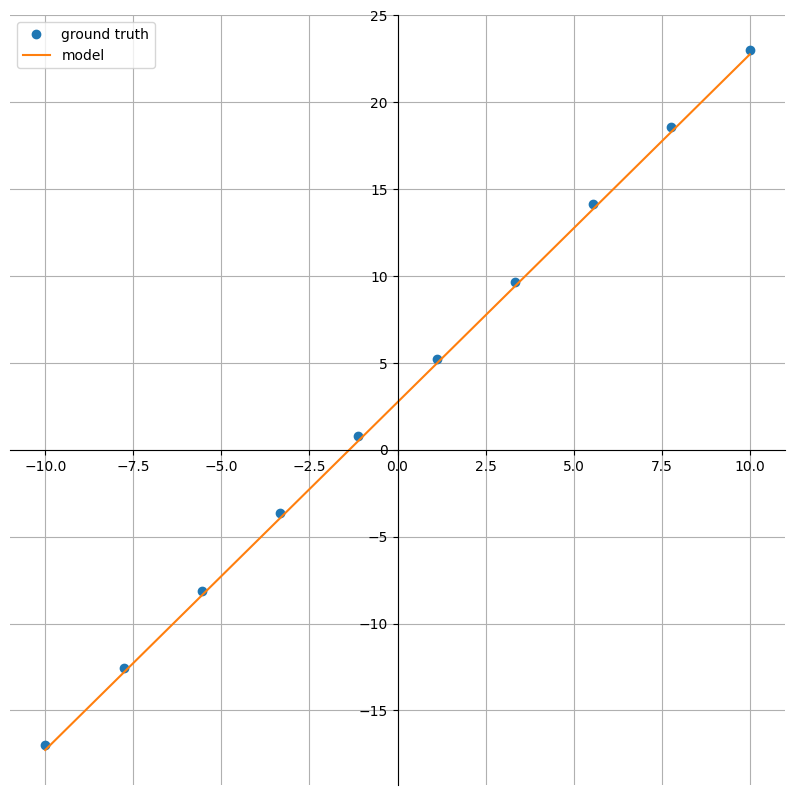

Epoach: 50; Train Loss: 0.021110064233653247


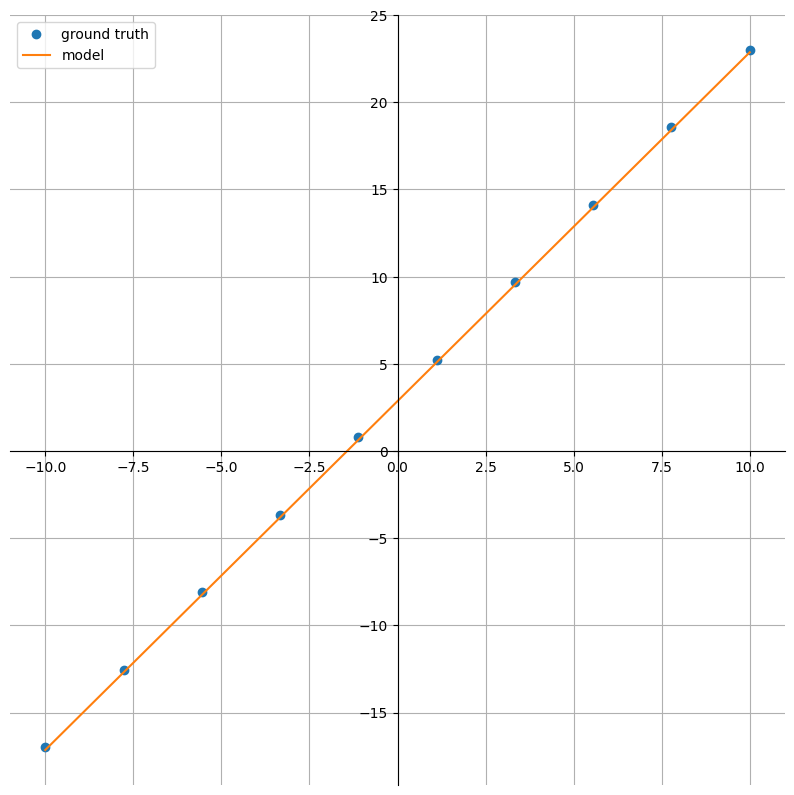

Epoach: 60; Train Loss: 0.005849908280652016


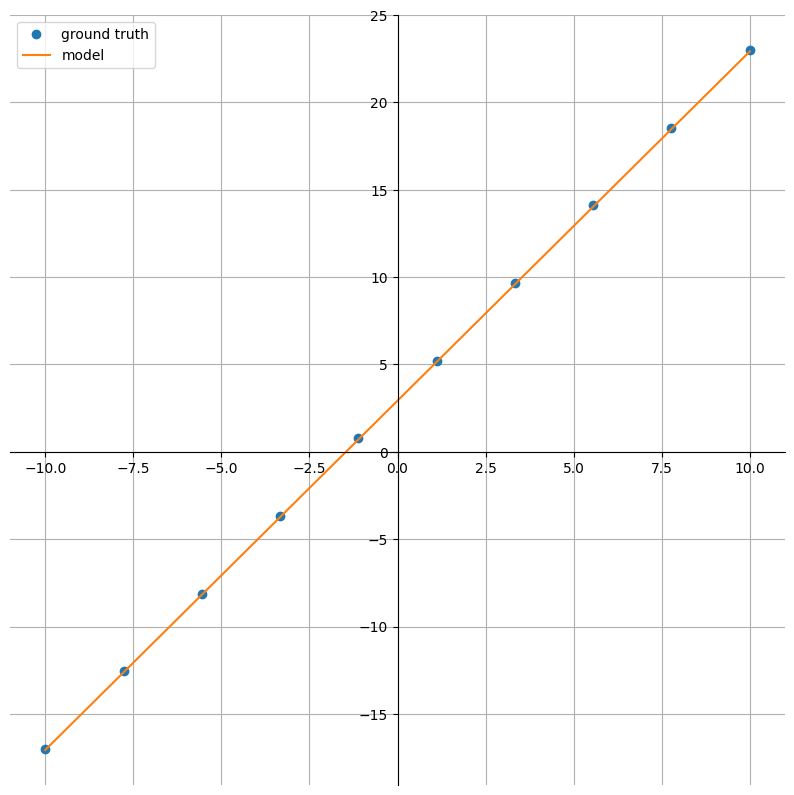

Epoach: 70; Train Loss: 0.001623741500225151


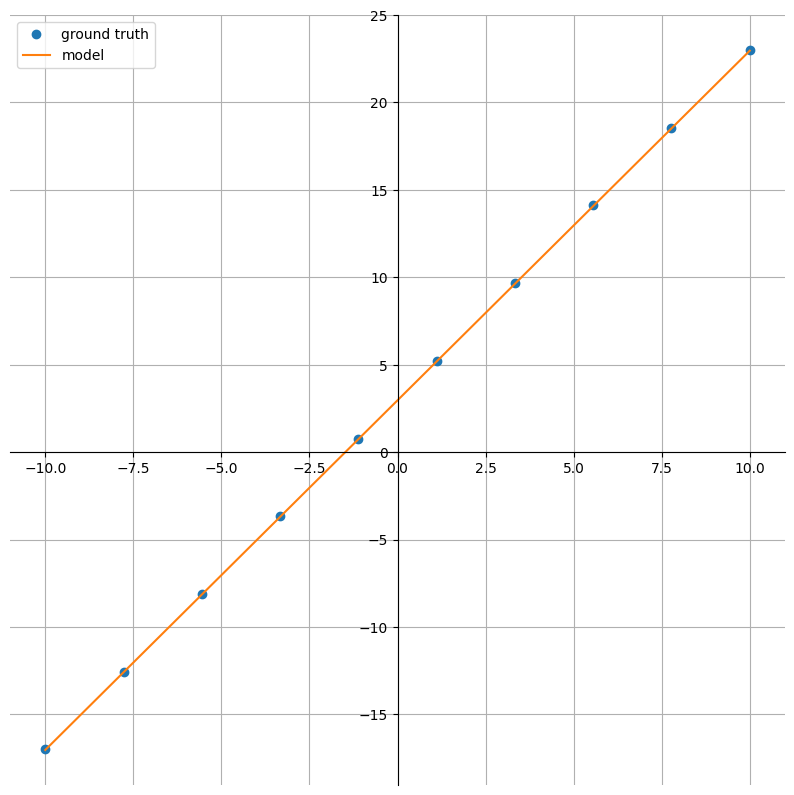

Epoach: 80; Train Loss: 0.0004510392463998869


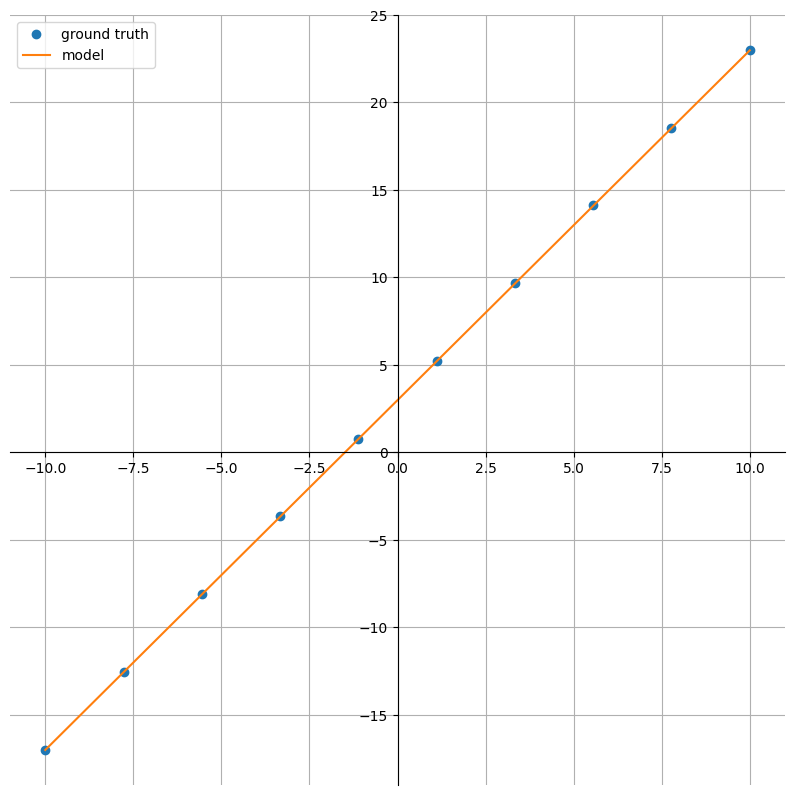

Epoach: 90; Train Loss: 0.00012522839551820653


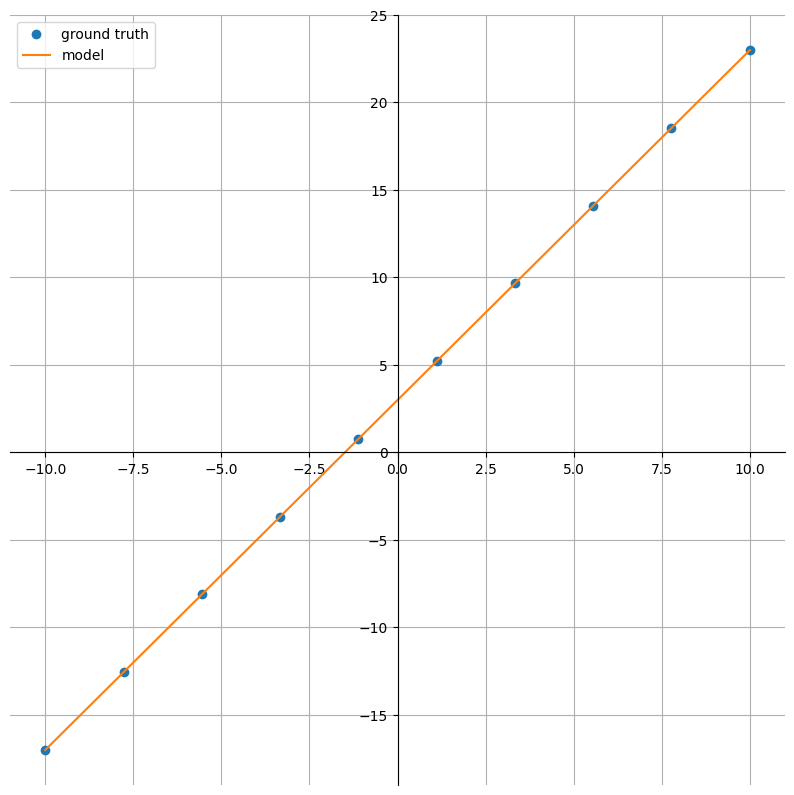

Epoach: 100; Train Loss: 3.4699413731686946e-05


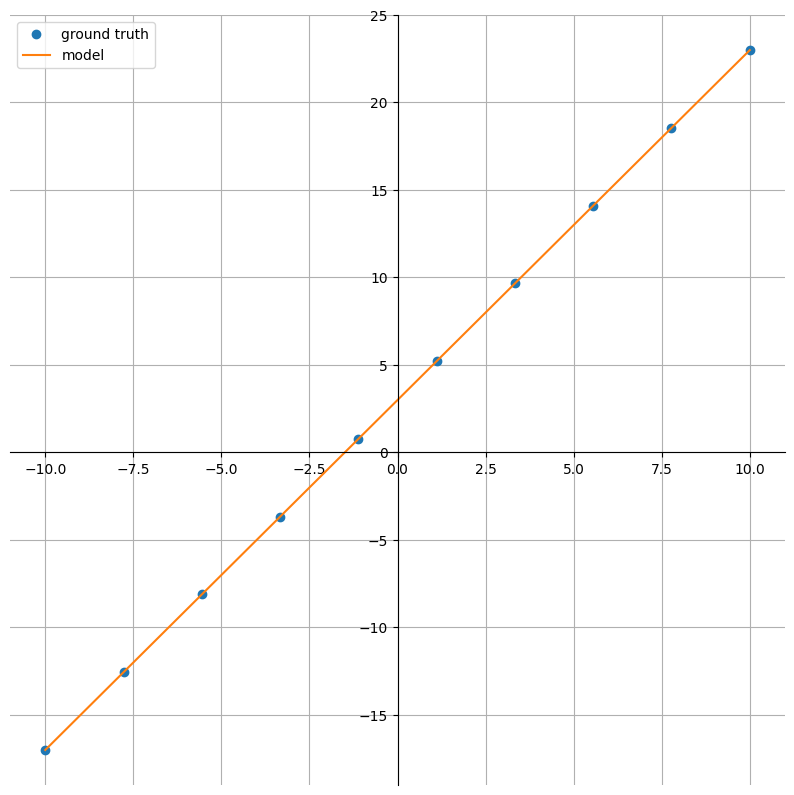

Epoach: 110; Train Loss: 9.638964115765702e-06


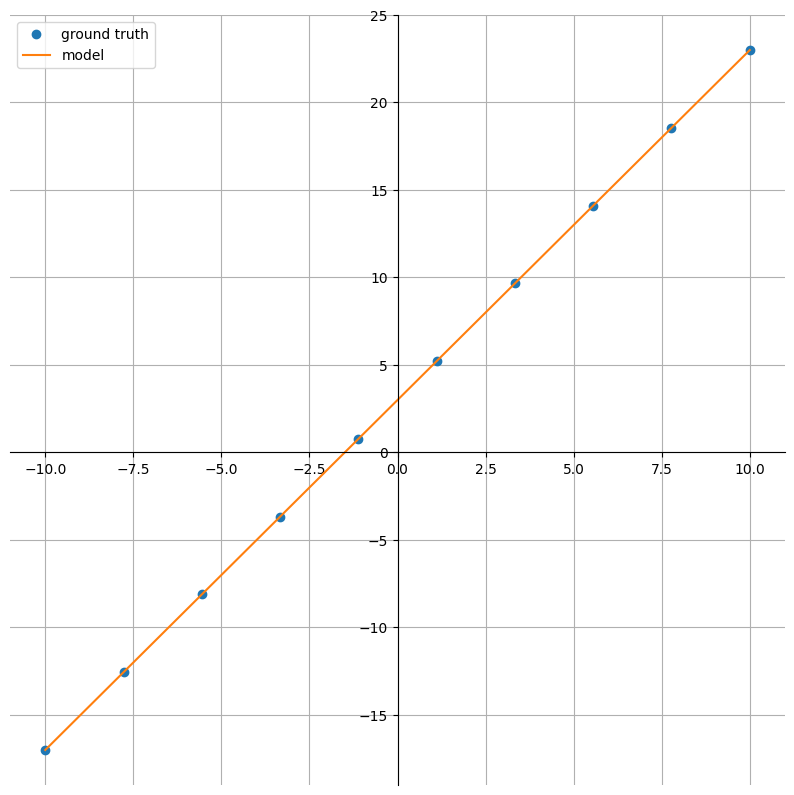

Epoach: 120; Train Loss: 2.6812325302216777e-06


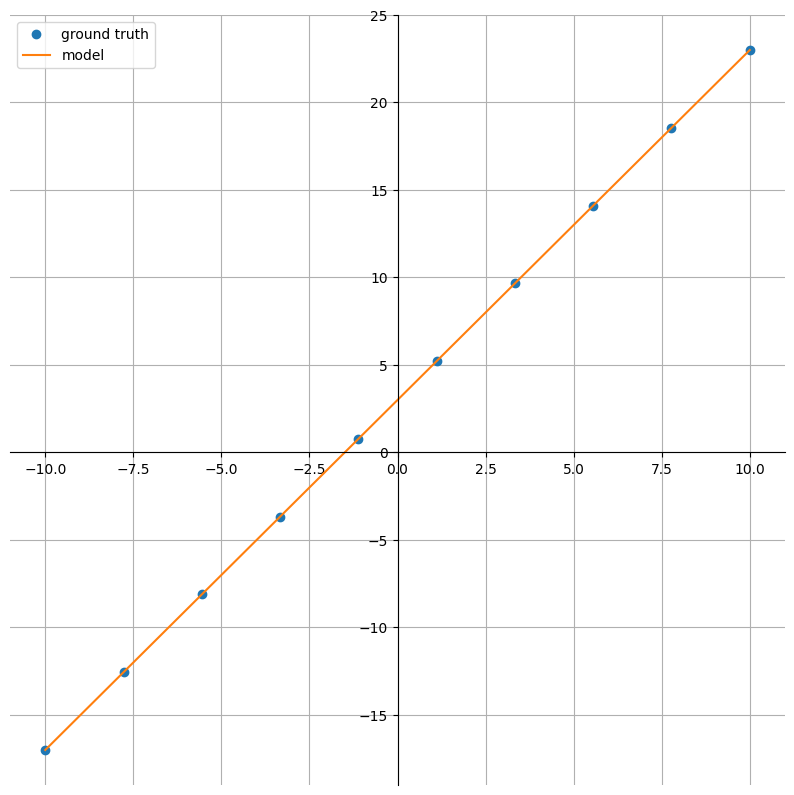

Epoach: 130; Train Loss: 7.432070958657278e-07


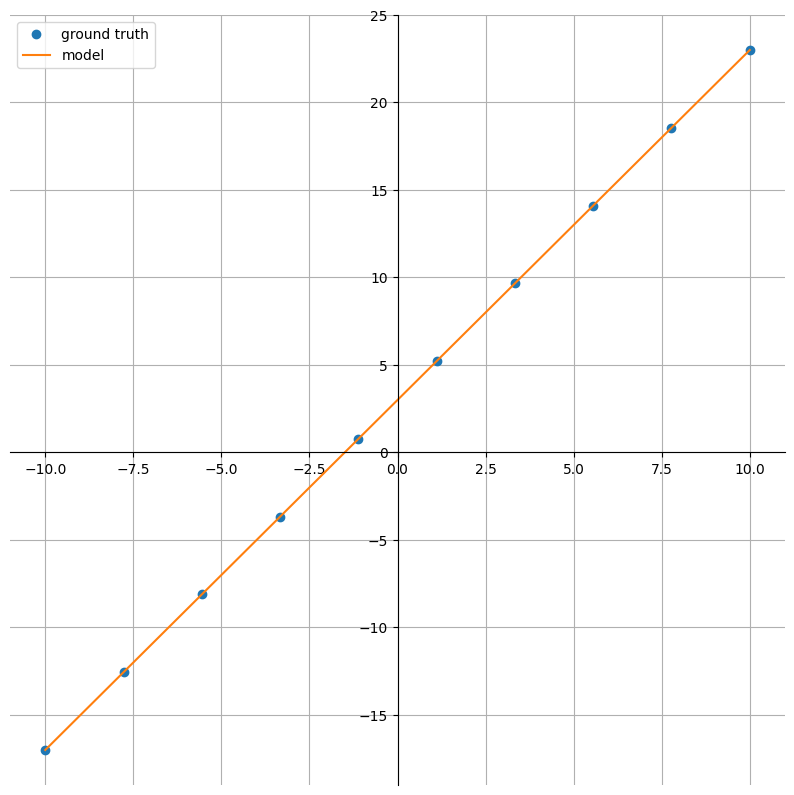

Epoach: 140; Train Loss: 2.076840188713902e-07


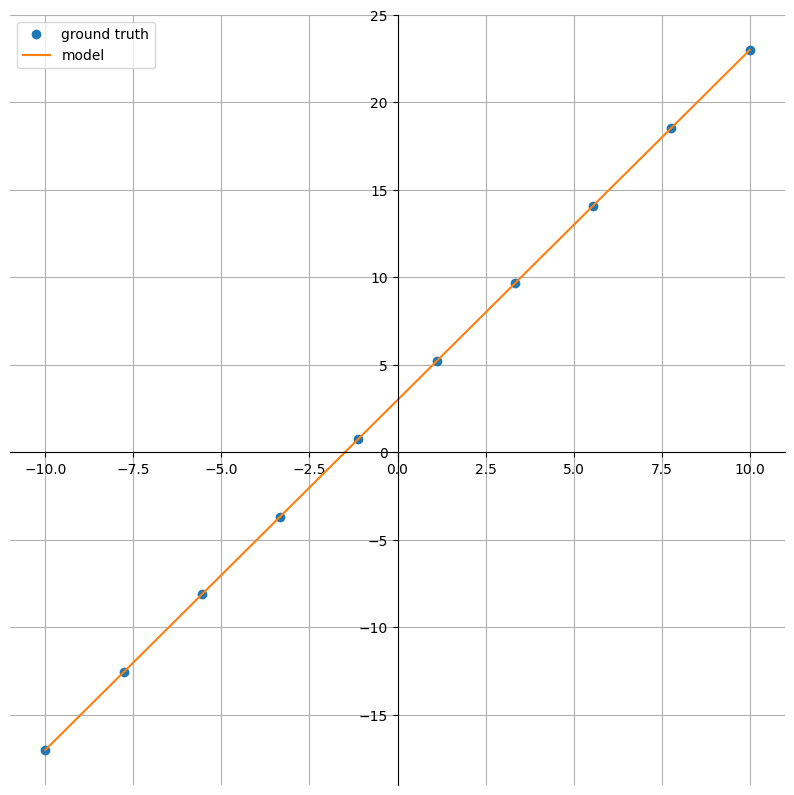

Epoach: 150; Train Loss: 5.933265634361362e-08


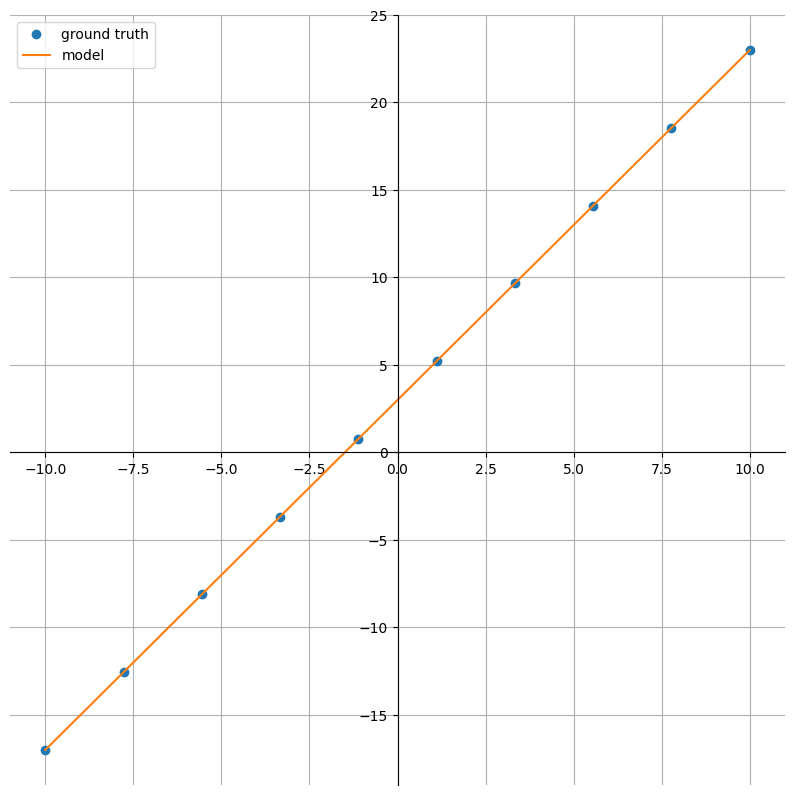

Epoach: 160; Train Loss: 1.800938376206318e-08


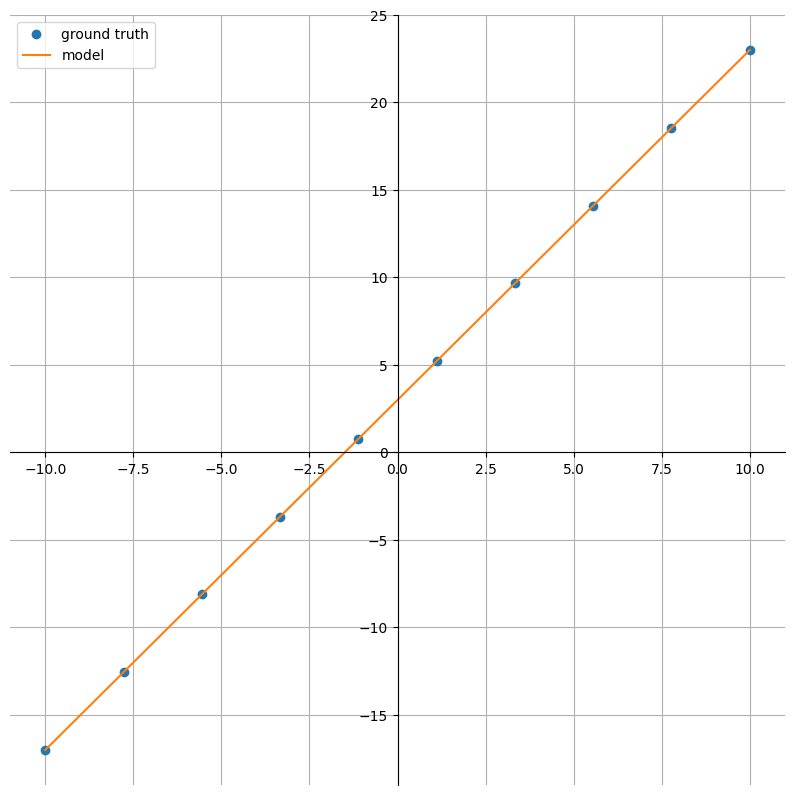

Epoach: 170; Train Loss: 3.5585634855506143e-09


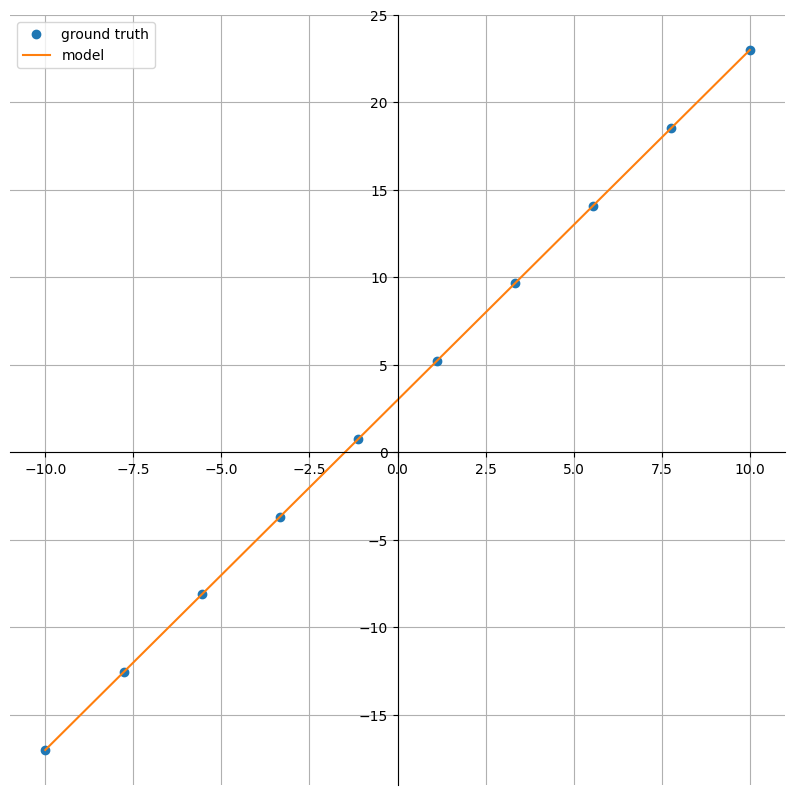

Epoach: 180; Train Loss: 3.419018429484666e-09


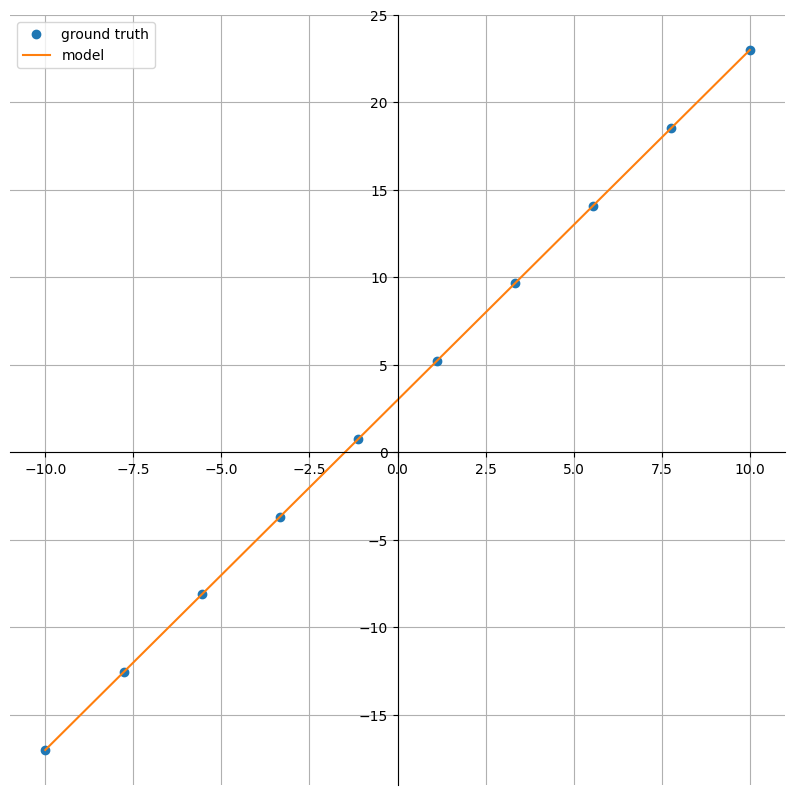

Epoach: 190; Train Loss: 3.325985251101393e-09


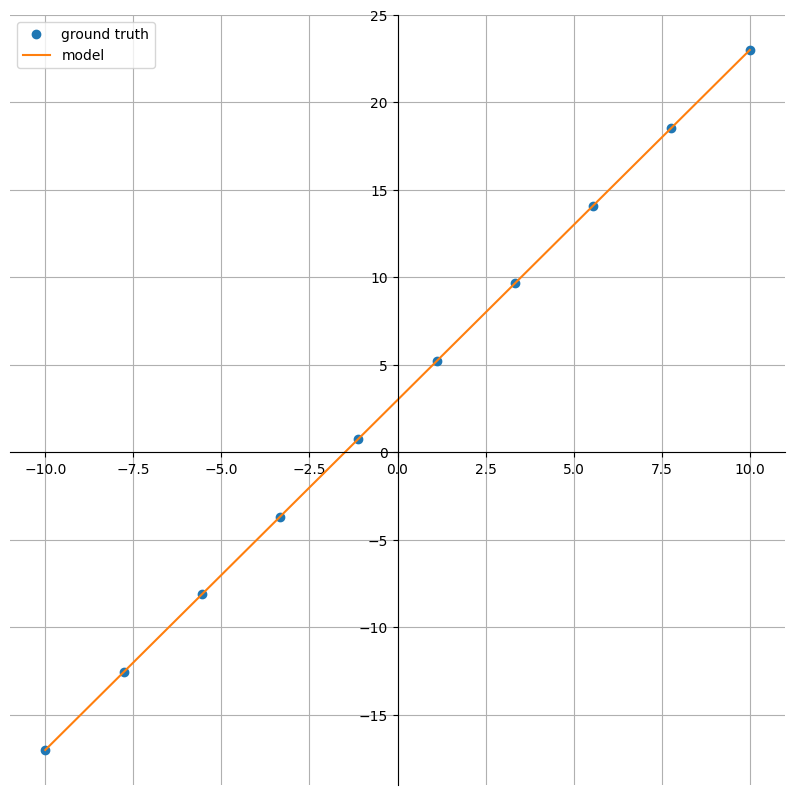

Epoach: 200; Train Loss: 3.3204091559602134e-09


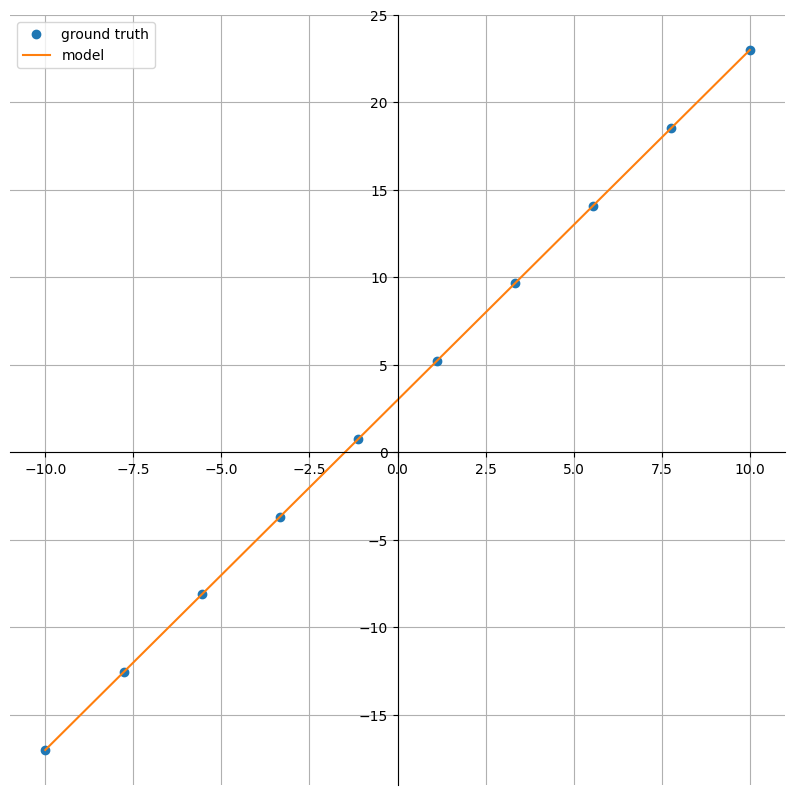

Test Loss: 3.2994103005279385e-09


In [37]:
epochs = 201
for t in range(epochs):
  train_loss = train(model, train_dataloader, lossfunc, optimizer)
  if t % 10 == 0:
    print(f'Epoach: {t}; Train Loss: {train_loss}')
    plot_comparinson(line, model)

test_loss = test(model, test_dataloader, lossfunc)
print(f'Test Loss: {test_loss}')